In [1]:
import warnings
warnings.filterwarnings('ignore')   # keep the notebook output readable

import glob
import logging
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # noqa: F401, registers the .rio accessor
from rasterio.warp import transform

import GRSl2bgen

logging.getLogger().setLevel(logging.WARNING)

# lighter figures for the documentation
%config InlineBackend.figure_formats = ['jpeg']
plt.rcParams['figure.dpi'] = 72

print(f'GRSl2bgen {GRSl2bgen.__version__}')

GRSl2bgen 1.0.0


In [2]:
l2a_path = '/data/satellite/Sentinel-2/L2A/28QCH/2025/04/06/S2C_MSIL2A_20250406T113341_N0511_R080_T28QCH_20250406T164815'
clon, clat = -16.52, 19.9          # centre of the area of interest (degrees)
width, height = 25000, 25000       # size of the area of interest (m)

prod = GRSl2bgen.Product(l2a_path)
(cx,), (cy,) = transform('EPSG:4326', prod.raster.rio.crs, [clon], [clat])
raster = prod.raster.sel(x=slice(cx - width / 2, cx + width / 2),
                         y=slice(cy + height / 2, cy - height / 2))

# keep the valid water pixels only (mask == 0)
Rrs = raster.Rrs.where(raster.mask == 0).load()
date = str(raster.time.dt.strftime('%Y-%m-%d').values)
dx, dy = (abs(r) for r in raster.rio.resolution())
print(f'{date}: {raster.sizes["y"]} x {raster.sizes["x"]} pixels of {dx:.0f} x {dy:.0f} m, '
      f'bands {Rrs.wl.values.tolist()} nm')

2025-04-06: 1170 x 1250 pixels of 20 x 20 m, bands [443, 490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190] nm


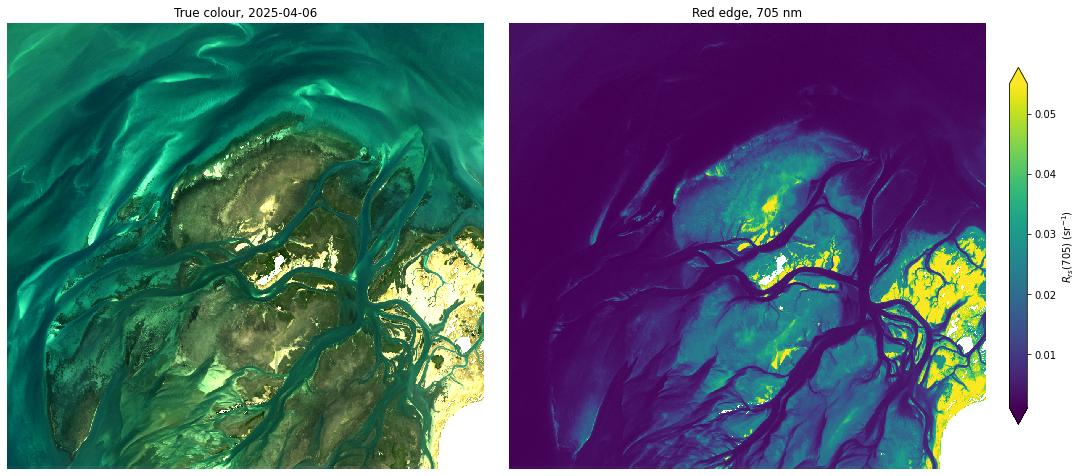

In [3]:
def show_map(ax, title):
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_axis_off()

rgb = Rrs.sel(wl=[665, 560, 490])
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5), constrained_layout=True)
rgb.plot.imshow(rgb='wl', robust=True, ax=axs[0])
show_map(axs[0], f'True colour, {date}')
Rrs.sel(wl=705).plot.imshow(robust=True, cmap='viridis', ax=axs[1],
                            cbar_kwargs={'label': r'$R_{rs}(705)$ (sr$^{-1}$)', 'shrink': 0.8})
show_map(axs[1], 'Red edge, 705 nm')

In [4]:
points = {
    'offshore':          (331000, 2208500),
    'green filament':    (337500, 2210800),
    'coastal green':     (329500, 2203500),
    'shoal':             (349000, 2207000),
    'channel':           (336630, 2201410),
    'turquoise channel': (333500, 2194500),
    'seagrass flat':     (338000, 2197500),
    'sand flat':         (344500, 2205500),
    'emerged seagrass':  (341500, 2201200),
}

half = 1.5 * dx   # half-width of the 3 x 3 window
spectra = []
for name, (x, y) in points.items():
    window = Rrs.sel(x=slice(x - half, x + half), y=slice(y + half, y - half))
    spectra.append(window.median(['x', 'y']).assign_coords(owt=name))

xowt_img = xr.concat(spectra, dim='owt').reset_coords(drop=True).transpose('owt', 'wl')
xowt_img.name = 'Rrs'
names = xowt_img.owt.values
Nowt = len(names)
colors = plt.get_cmap('tab10')(np.arange(Nowt))
cmap_img = mpl.colors.ListedColormap(colors)
xowt_img

<xarray.DataArray 'Rrs' (owt: 9, wl: 11)> Size: 792B
array([[ 9.8000e-03,  1.4730e-02,  1.6435e-02,  3.3550e-03,  1.9200e-03,
         7.8500e-04,  6.6000e-04,  8.8500e-04,  4.6000e-04,  6.2500e-04,
         1.4500e-04],
       [ 1.3675e-02,  2.1290e-02,  2.8935e-02,  4.5850e-03,  2.1300e-03,
         8.0000e-04,  8.3000e-04,  5.1000e-04,  6.6500e-04,  8.0000e-04,
         2.2500e-04],
       [ 8.3000e-03,  1.4035e-02,  1.6155e-02,  2.1000e-03,  1.2650e-03,
         5.2000e-04,  4.2000e-04,  7.1500e-04,  5.4000e-04,  6.1000e-04,
         5.0000e-06],
       [ 1.1660e-02,  1.6715e-02,  2.1655e-02,  4.2400e-03,  2.2550e-03,
         1.1300e-03,  1.0650e-03,  8.9000e-04,  8.6000e-04,  6.6000e-04,
         2.0500e-04],
       [ 7.2800e-03,  7.8700e-03,  1.1450e-02,  4.7700e-03,  7.3900e-03,
         1.3500e-03,  1.4700e-03,  1.2200e-03,  8.0000e-04,  6.0000e-04,
         5.0000e-05],
       [ 8.8950e-03,  1.2680e-02,  1.6940e-02,  7.5550e-03,  5.6700e-03,
         1.1150e-03,  9.8500e-04,  1.0550e-03,  6.7500e-04,  6.1000e-04,
         1.4500e-04],
       [ 8.6250e-03,  1.1910e-02,  1.7535e-02,  1.1955e-02,  1.6775e-02,
         3.0200e-03,  3.4400e-03,  2.7700e-03,  8.9000e-04,  4.3000e-04,
         4.0000e-05],
       [ 6.8750e-03,  8.8800e-03,  1.4240e-02,  8.7300e-03,  1.2370e-02,
         2.8150e-03,  3.3600e-03,  2.7550e-03,  1.1300e-03,  2.7000e-04,
         1.0000e-05],
       [ 6.7400e-03,  8.7950e-03,  1.4780e-02,  1.2025e-02,  2.3795e-02,
         2.5505e-02,  2.9120e-02,  2.8275e-02,  2.5510e-02,  6.0000e-04,
        -9.1500e-04]])
Coordinates:
  * wl       (wl) int64 88B 443 490 560 665 705 740 783 842 865 1610 2190
  * owt      (owt) <U17 612B 'offshore' 'green filament' ... 'emerged seagrass'

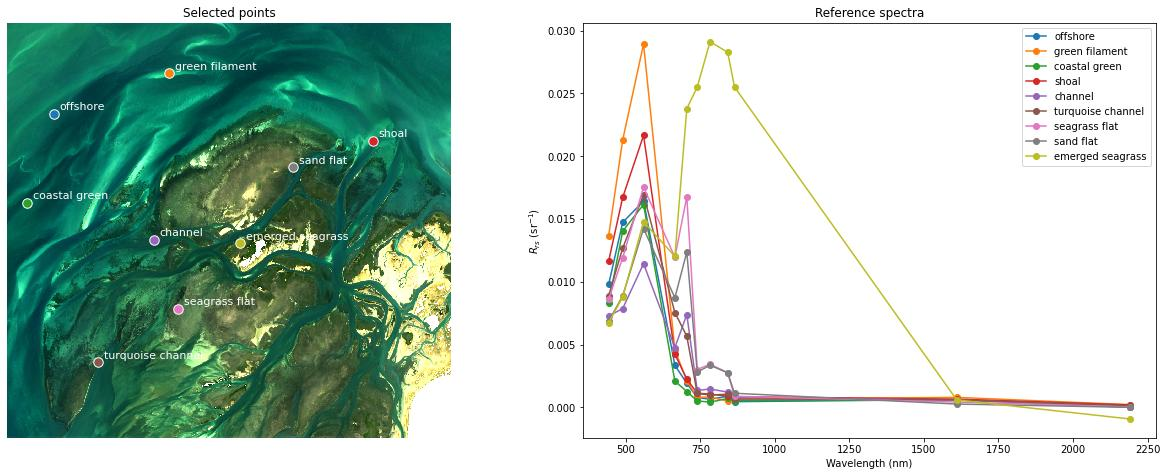

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
rgb.plot.imshow(rgb='wl', robust=True, ax=axs[0])
for i, (name, (x, y)) in enumerate(points.items()):
    axs[0].scatter(x, y, color=colors[i], edgecolor='white', s=90, zorder=10)
    axs[0].annotate(name, (x, y), xytext=(6, 4), textcoords='offset points', color='white', fontsize=11)
show_map(axs[0], 'Selected points')

for i, name in enumerate(names):
    xowt_img.sel(owt=name).plot(ax=axs[1], color=colors[i], marker='o', label=name)
axs[1].set_title('Reference spectra')
axs[1].set_xlabel('Wavelength (nm)')
axs[1].set_ylabel(r'$R_{rs}$ (sr$^{-1}$)')
axs[1].legend(fontsize=10);

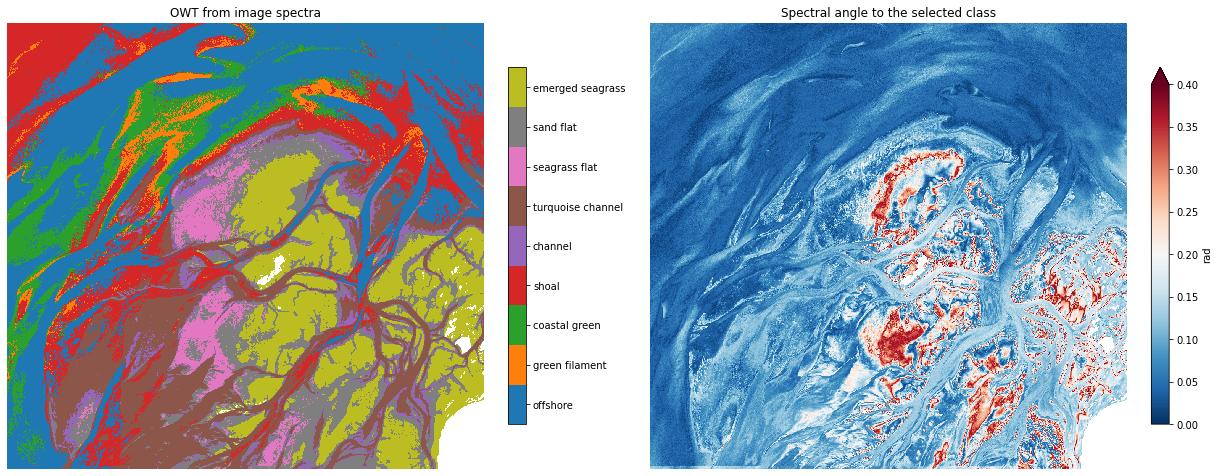

In [6]:
owt_img = GRSl2bgen.OWT(raster, xowt=xowt_img)
xowt_prod = owt_img.multi_process().where(raster.mask == 0).compute()

def show_owt(ax, prod, labels, cmap, title):
    """Map an OWT index with the class names on the colour bar."""
    n = len(labels)
    im = prod.owt_index.plot.imshow(ax=ax, cmap=cmap, vmin=0.5, vmax=n + 0.5,
                                    cbar_kwargs={'ticks': range(1, n + 1), 'shrink': 0.8, 'label': ''})
    im.colorbar.ax.set_yticklabels(labels)
    show_map(ax, title)

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], xowt_prod, names, cmap_img, 'OWT from image spectra')
xowt_prod.owt_dist.plot.imshow(ax=axs[1], cmap='RdBu_r', vmin=0, vmax=0.4,
                               cbar_kwargs={'label': 'rad', 'shrink': 0.8})
show_map(axs[1], 'Spectral angle to the selected class')

,pixels,area (km2),share (%)
OWT,,,
offshore,391820,156.73,27.23
green filament,36730,14.69,2.55
coastal green,104681,41.87,7.28
shoal,210618,84.25,14.64
channel,56319,22.53,3.91
turquoise channel,230282,92.11,16.01
seagrass flat,46864,18.75,3.26
sand flat,156904,62.76,10.91
emerged seagrass,204483,81.79,14.21


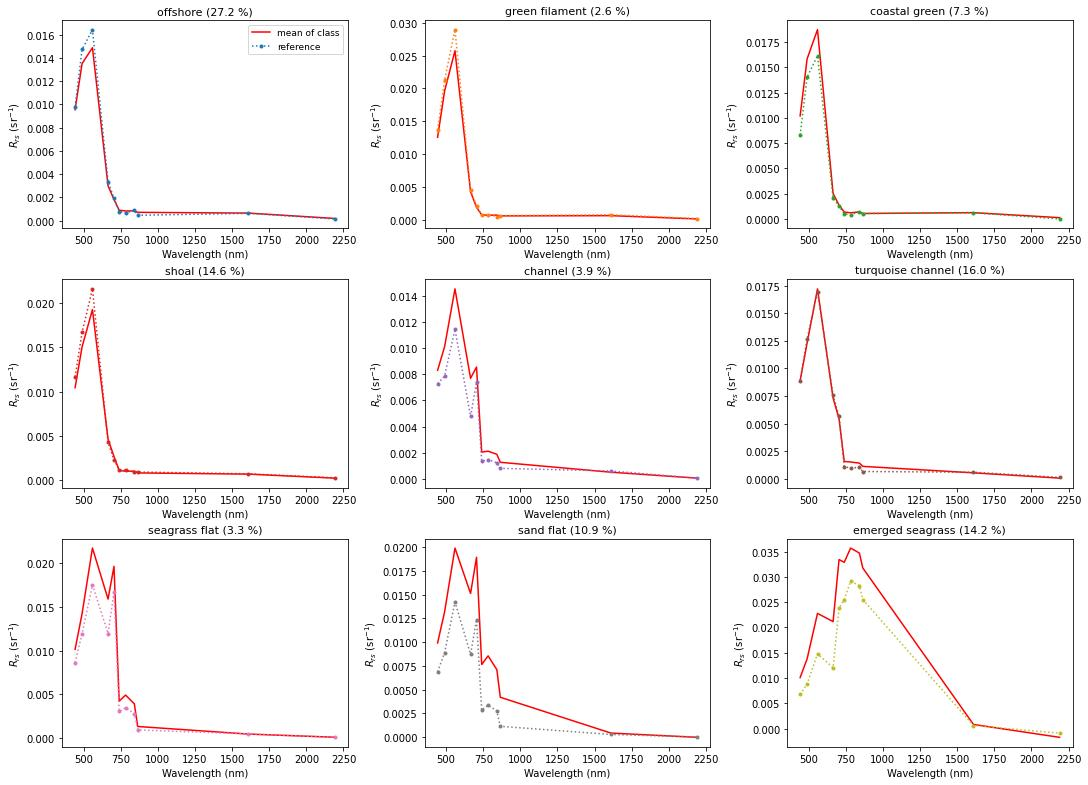

In [7]:
pixel_area_km2 = dx * dy * 1e-6
index = xowt_prod.owt_index
Ntot = int(index.count())

ncols = 3
nrows = int(np.ceil(Nowt / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), constrained_layout=True)
rows = []
for j, (ax, name) in enumerate(zip(axs.ravel(), names), start=1):
    Rrs_j = Rrs.where(index == j)
    Npix = int(Rrs_j.isel(wl=0).count())
    rows.append({'OWT': name, 'pixels': Npix, 'area (km2)': Npix * pixel_area_km2,
                 'share (%)': 100 * Npix / Ntot})
    if Npix:
        Rrs_j.mean(['x', 'y']).plot(ax=ax, color='r', label='mean of class')
    xowt_img.sel(owt=name).plot(ax=ax, color=colors[j - 1], ls=':', marker='o', ms=3, label='reference')
    ax.set_title(f'{name} ({100 * Npix / Ntot:.1f} %)', fontsize=11)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(r'$R_{rs}$ (sr$^{-1}$)')
axs.ravel()[0].legend(fontsize=9)
for ax in axs.ravel()[Nowt:]:
    ax.set_axis_off()
pd.DataFrame(rows).set_index('OWT').round(2)

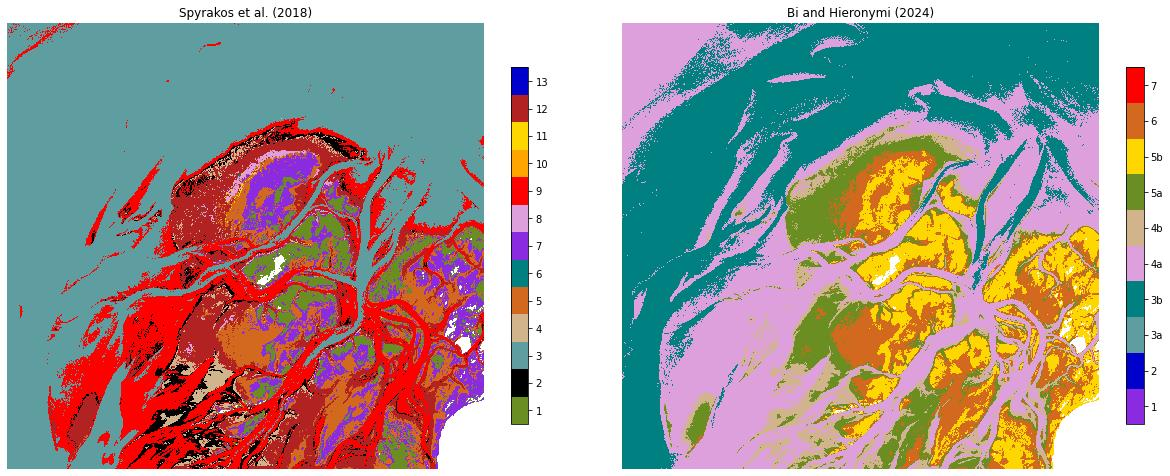

In [8]:
owt_spy = GRSl2bgen.OWT(raster, owt_database='Spyrakos2018')
prod_spy = owt_spy.multi_process().where(raster.mask == 0).compute()
owt_bi = GRSl2bgen.OWT(raster, owt_database='Bi2024')
prod_bi = owt_bi.multi_process().where(raster.mask == 0).compute()

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], prod_spy, [str(i) for i in range(1, 14)], owt_spy.cmap_owt, 'Spyrakos et al. (2018)')
show_owt(axs[1], prod_bi, ['1', '2', '3a', '3b', '4a', '4b', '5a', '5b', '6', '7'], owt_bi.cmap_owt,
         'Bi and Hieronymi (2024)')

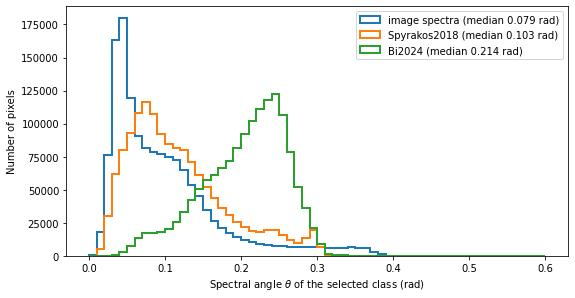

In [9]:
angles = {'image spectra': xowt_prod.owt_dist, 'Spyrakos2018': prod_spy.owt_dist, 'Bi2024': prod_bi.owt_dist}
bins = np.linspace(0, 0.6, 61)
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, da in angles.items():
    values = da.values.ravel()
    values = values[np.isfinite(values)]
    ax.hist(values, bins=bins, histtype='step', lw=2, label=f'{label} (median {np.median(values):.3f} rad)')
ax.set_xlabel(r'Spectral angle $\theta$ of the selected class (rad)')
ax.set_ylabel('Number of pixels')
ax.legend();

In [10]:
owt_dir = '/DATA/data/model/owt'

gernez = []
for file in sorted(glob.glob(os.path.join(owt_dir, 'Gernez_50_shades_Rrs_cluster_*.txt'))):
    name = file.split('_')[-1].replace('.txt', '')
    # one column per in situ spectrum of the cluster
    cluster = pd.read_csv(file, sep=r'\s+').set_index('wavelength').stack().to_xarray()
    gernez.append(cluster.median('level_1').assign_coords(owt=name))
gernez = xr.concat(gernez, 'owt').rename({'wavelength': 'wl'}).reset_coords(drop=True)
print(gernez.owt.values, 'at', gernez.wl.values, 'nm')

['Cyanobacteria' 'Dinoflagellates1' 'Dinoflagellates2' 'Lepidodinium'
 'Mesodinium' 'red'] at [443 492 560 665 704 740 783 834 865] nm


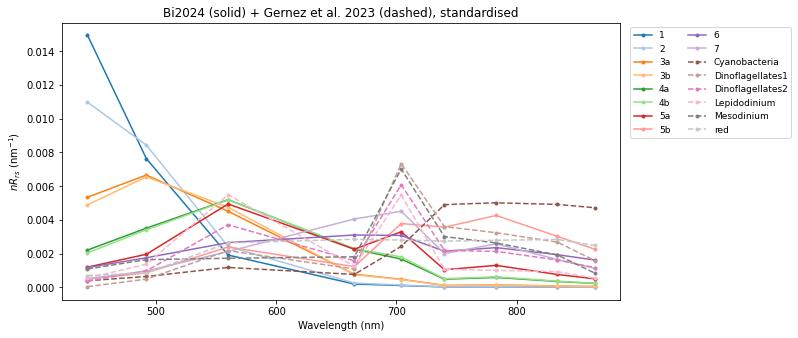

In [11]:
def standardise(spectra):
    return spectra / spectra.integrate('wl')

bi = owt_bi.owt.interp(wl=gernez.wl)          # Bi2024 standardised mean spectra (m_nRrs)
bi['owt'] = ['1', '2', '3a', '3b', '4a', '4b', '5a', '5b', '6', '7']
xowt_comb = xr.concat([bi, gernez], dim='owt').dropna('wl')
names_comb = xowt_comb.owt.values
Ncomb = len(names_comb)
cmap_comb = mpl.colors.ListedColormap(plt.get_cmap('tab20')(np.arange(Ncomb)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(names_comb):
    standardise(xowt_comb).sel(owt=name).plot(ax=ax, color=cmap_comb(i), marker='o', ms=3,
                                 ls='-' if i < 10 else '--', label=name)
ax.set_title('Bi2024 (solid) + Gernez et al. 2023 (dashed), standardised')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$nR_{rs}$ (nm$^{-1}$)')
ax.legend(ncol=2, fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left');

In [12]:
ta2025 = xr.open_dataarray(GRSl2bgen.owt.OWT_tarasenko2025_file)
print('same classes:', sorted(ta2025.owt.values) == sorted(names_comb))
print('same spectra:', np.allclose(ta2025.transpose('owt', 'wl').values,
                                   xowt_comb.sel(owt=ta2025.owt.values).values, rtol=1e-6))
# class numbers used in owt_index_Ta2025
pd.Series(ta2025.owt.values, index=range(1, len(ta2025.owt) + 1), name='Ta2025 class').to_frame().T

same classes: True
same spectra: True


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Ta2025 class,1,2,3a,3b,4a,4b,5a,5b,6,7,Cyanobacteria,Mesodinium,Dinoflagellates2,red,Dinoflagellates1,Lepidodinium


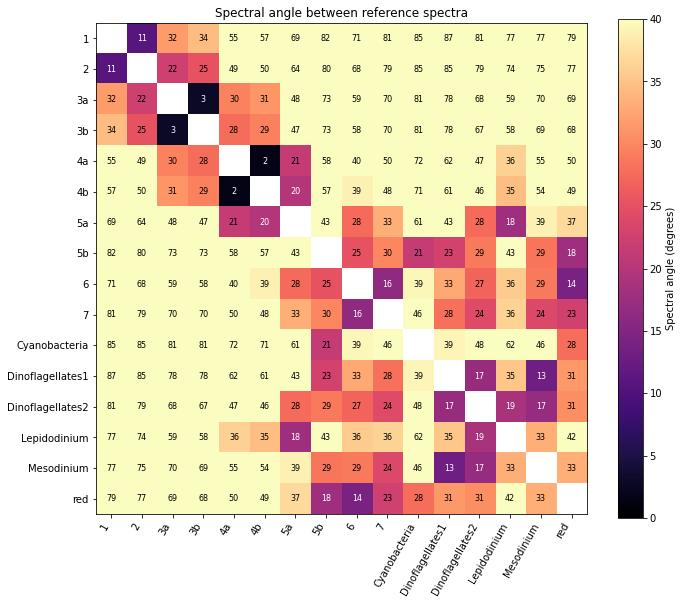

In [13]:
unit = xowt_comb / np.sqrt((xowt_comb ** 2).sum('wl'))
cosines = np.clip(unit.values @ unit.values.T, -1, 1)
angle_matrix = pd.DataFrame(np.degrees(np.arccos(cosines)), index=names_comb, columns=names_comb)
np.fill_diagonal(angle_matrix.values, np.nan)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(angle_matrix, cmap='magma', vmin=0, vmax=40)
ax.set_xticks(range(Ncomb), names_comb, rotation=60, ha='right')
ax.set_yticks(range(Ncomb), names_comb)
for i in range(Ncomb):
    for j in range(Ncomb):
        if i != j:
            ax.text(j, i, f'{angle_matrix.iat[i, j]:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if angle_matrix.iat[i, j] < 20 else 'black')
fig.colorbar(im, ax=ax, label='Spectral angle (degrees)')
ax.set_title('Spectral angle between reference spectra');

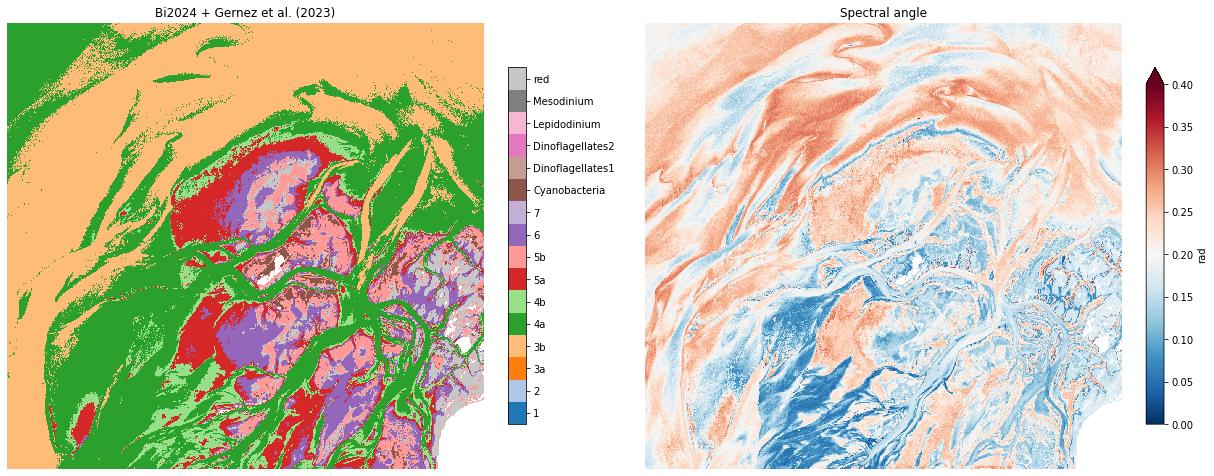

In [14]:
owt_comb = GRSl2bgen.OWT(raster, xowt=xowt_comb)
prod_comb = owt_comb.multi_process().where(raster.mask == 0).compute()

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], prod_comb, names_comb, cmap_comb, 'Bi2024 + Gernez et al. (2023)')
prod_comb.owt_dist.plot.imshow(ax=axs[1], cmap='RdBu_r', vmin=0, vmax=0.4,
                               cbar_kwargs={'label': 'rad', 'shrink': 0.8})
show_map(axs[1], 'Spectral angle')

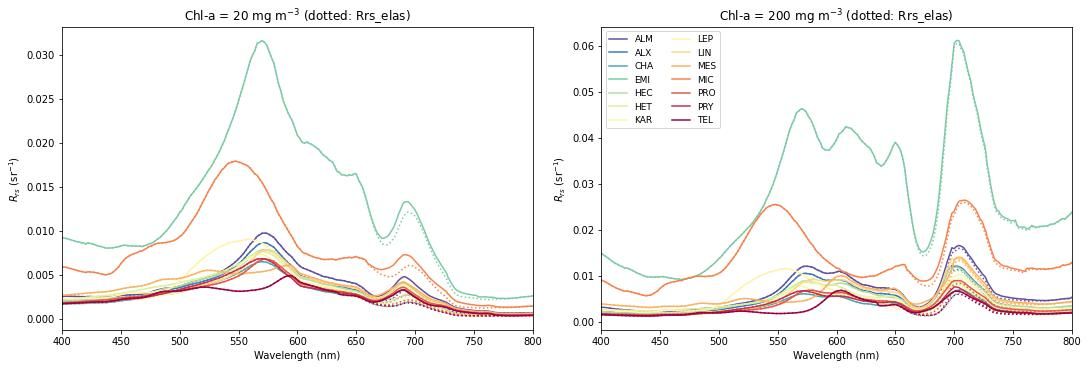

In [15]:
hablab = xr.open_dataset(os.path.join(owt_dir, 'hablab_owt_chl20_chl_200.nc'))
species = hablab.species.values
cmap_sp = plt.get_cmap('Spectral_r')

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=False, constrained_layout=True)
for ax, chl in zip(axs, hablab.chl.values):
    for i, sp in enumerate(species):
        color = cmap_sp(i / (len(species) - 1))
        sel = hablab.sel(chl=chl, species=sp)
        sel.Rrs_elas.plot(ax=ax, color=color, ls=':')
        sel.Rrs_tot.plot(ax=ax, color=color, label=sp)
    ax.set_title(f'Chl-a = {chl} mg m$^{{-3}}$ (dotted: Rrs_elas)')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(r'$R_{rs}$ (sr$^{-1}$)')
    ax.set_xlim(400, 800)
axs[1].legend(ncol=2, fontsize=9);

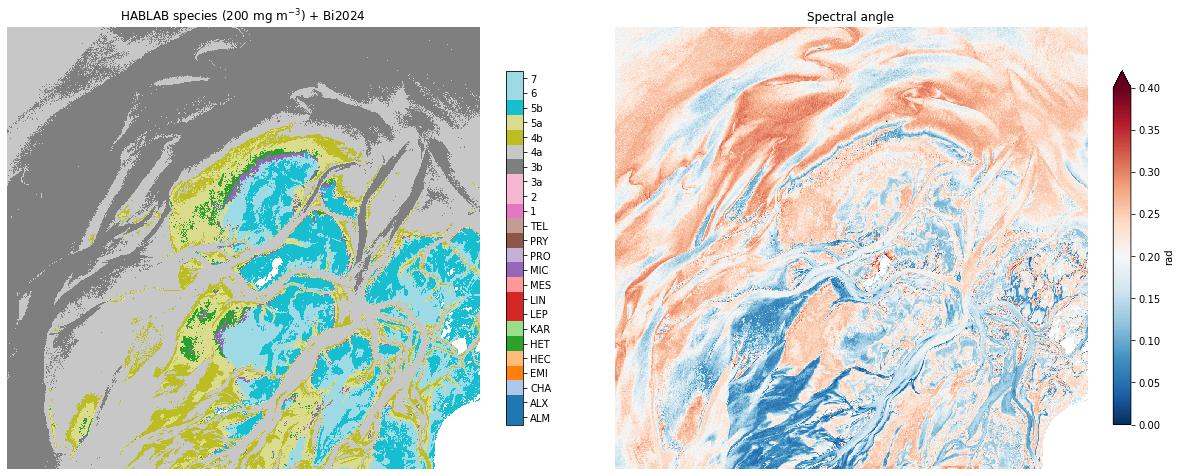

In [16]:
sp_200 = hablab.Rrs_tot.sel(chl=200).rename({'species': 'owt'}).reset_coords(drop=True)
xowt_hab = standardise(xr.concat([sp_200.interp(wl=gernez.wl), bi], dim='owt').dropna('wl'))
names_hab = xowt_hab.owt.values
cmap_hab = mpl.colors.ListedColormap(plt.get_cmap('tab20', len(names_hab))(np.arange(len(names_hab))))

owt_hab = GRSl2bgen.OWT(raster, xowt=xowt_hab)
prod_hab = owt_hab.multi_process().where(raster.mask == 0).compute()

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], prod_hab, names_hab, cmap_hab, 'HABLAB species (200 mg m$^{-3}$) + Bi2024')
prod_hab.owt_dist.plot.imshow(ax=axs[1], cmap='RdBu_r', vmin=0, vmax=0.4,
                              cbar_kwargs={'label': 'rad', 'shrink': 0.8})
show_map(axs[1], 'Spectral angle')

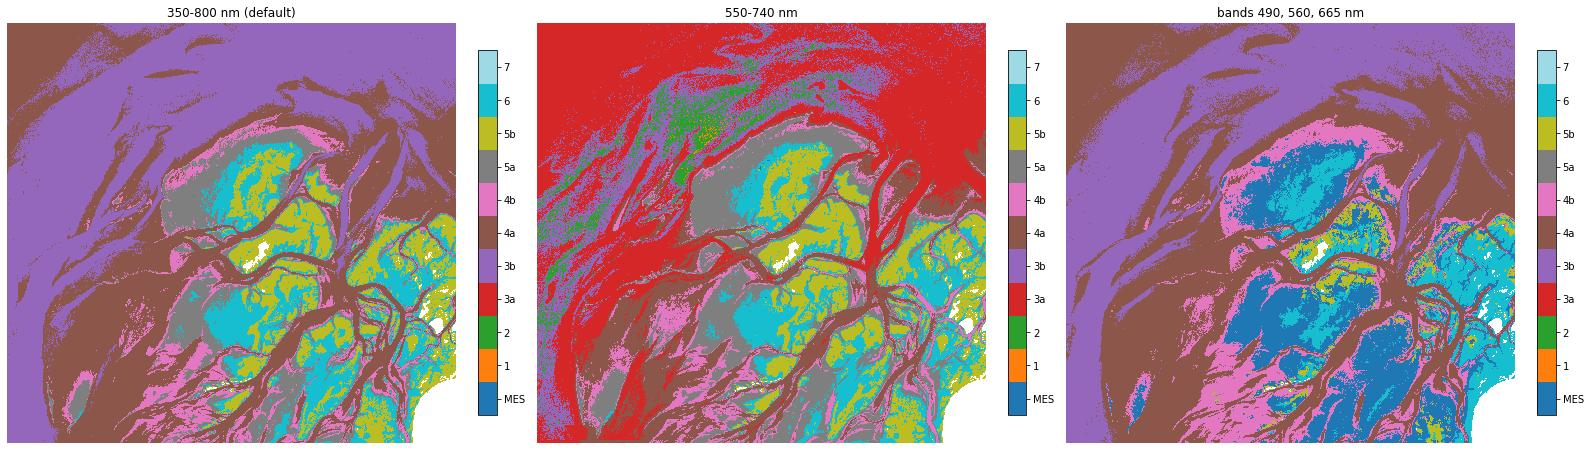

In [17]:
xowt_mes = standardise(xr.concat([sp_200.sel(owt=['MES']).interp(wl=gernez.wl), bi], dim='owt').dropna('wl'))
names_mes = xowt_mes.owt.values
cmap_mes = mpl.colors.ListedColormap(plt.get_cmap('tab20', len(names_mes))(np.arange(len(names_mes))))

fig, axs = plt.subplots(1, 3, figsize=(22, 6.5), constrained_layout=True)
settings = [('350-800 nm (default)', raster, {}),
            ('550-740 nm', raster, {'wl_range': slice(550, 740)}),
            ('bands 490, 560, 665 nm', raster.sel(wl=[490, 560, 665]), {})]
for ax, (title, image, kwargs) in zip(axs, settings):
    prod = GRSl2bgen.OWT(image, xowt=xowt_mes, **kwargs).multi_process().where(raster.mask == 0).compute()
    show_owt(ax, prod, names_mes, cmap_mes, title)